### Brownian Motion, Diffusions, and Langevin Dynamics

In [141]:
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.special import gamma

In general, a diffusion follows the SDE 

$$dX(t)=\mu(t,X(t))dt + \sigma(t,X(t))dW(t)$$

where $\mu(t,x)$ is the drift, and $\sigma(t,x)$ is the diffusion part. $W(t)$ is a brownian motion (basically a white noise process with independent increments, $W(t)-W(s)\sim \mathcal{N}(0,t-s)$). The nice thing about SDE is we can do calculus with them using itos formula:

$$df(X(t))=f'(X(t))dX(t) + \frac{1}{2}f''(X(t))dX(t)dX(t).$$

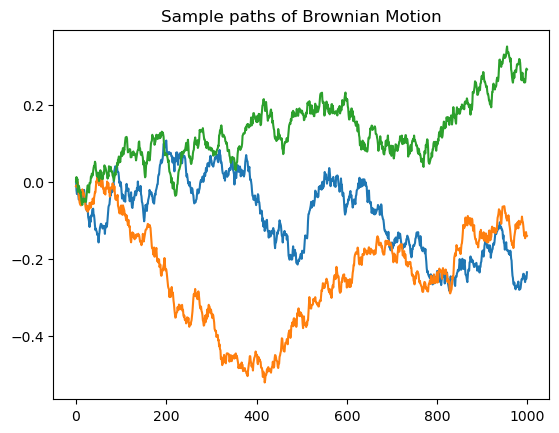

In [209]:
T=10
bins = 1000
dt = T/bins
samples = 3


time = np.linspace(0,T, bins)
gaussians = np.random.normal(loc=0.0, scale=dt, size=(bins,samples))
W = np.cumsum(gaussians, axis=0)

plt.title("Sample paths of Brownian Motion")
plt.plot(W)
plt.show()

To numerically simulate an SDE, we use the Euler-Maryumara method.

### Euler-Maryumara

Let $0=t_0< t_1< \dots < t_n=T$. We can discretize our diffusion as $$dX(t)=\mu(t,X(t))dt + \sigma(t,X(t))dW(t).$$

$$X(t_i)-X(t_{i-1}) = \mu(t_i,X(t_{i-1}))\Delta t + \sigma(t_i,X(t_{i-1}))\Delta W(t_i)$$
Where $\Delta W(t_i) \sim \mathcal{N}(0,\Delta t )$.

### Brownian Motion With Constant Drift 

$$dX(t)=a dt + \sigma dW(t).$$

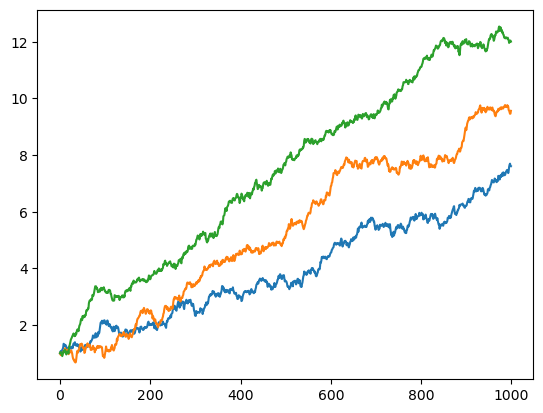

In [107]:
T=10
bins = 1000
dt = T/bins
samples = 3

a_var = 1
sigma_var=6

def mu(t, x):
    return a_var

def sigma(t, x):
    return sigma_var


for _ in range(samples):
    X = np.ones(bins)*X_0

    for i in range(1, bins):
        X[i] = X[i-1] + mu(i*dt, X[i-1])*dt + sigma(i*dt, X[i-1])*np.random.normal(0,dt)
    plt.plot(X)
plt.show()

### Geometric Brownian Motion Process

$$dX(t)=X(t)dt + X(t)dW(t).$$

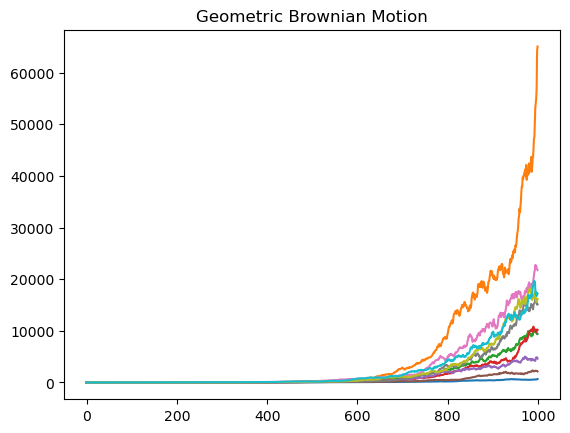

In [108]:
T=10
bins = 1000
dt = T/bins
samples = 10

sigma_var=3
mu_var = 1

def mu(t, x):
    return mu_var*x

def sigma(t, x):
    return sigma_var*x


for _ in range(samples):
    X = np.ones(bins)*X_0

    for i in range(1, bins):
        X[i] = X[i-1] + mu(i*dt, X[i-1])*dt + sigma(i*dt, X[i-1])*np.random.normal(0,dt)
    plt.plot(X)

plt.title("Geometric Brownian Motion")    
plt.show()

### Ornstein-Uhlenbeck Process (mean reversion)

$$dX(t)=-\theta X(t)dt + \sigma dW(t).$$

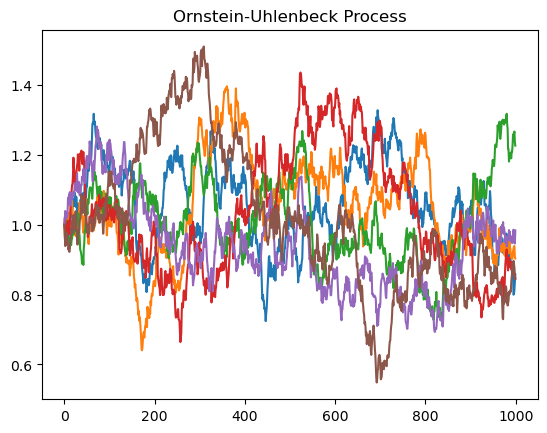

In [109]:
T=10
bins = 1000
dt = T/bins
samples = 6

theta_var=0.5
sigma_var=2
mu_var = 1

X_0=1

def mu(t, x):
    return theta_var*(mu_var-x)

def sigma(t, x):
    return sigma_var


for _ in range(samples):
    X = np.ones(bins)*X_0

    for i in range(1, bins):
        X[i] = X[i-1] + mu(i*dt, X[i-1])*dt + sigma(i*dt, X[i-1])*np.random.normal(0,dt)
    plt.plot(X)

plt.title("Ornstein-Uhlenbeck Process")
plt.show()

### Langevin Diffusion

This process is interesting. We can construct a process with $\pi(x)$ as its stationary distribution. More specifically, $X(t)$ converges in distribution to $\pi$ as $t\to \infty$. The SDE for this equation is 

$$d X(t)=\nabla \log \pi(X(t))dt+\sqrt{2} dW(t).$$

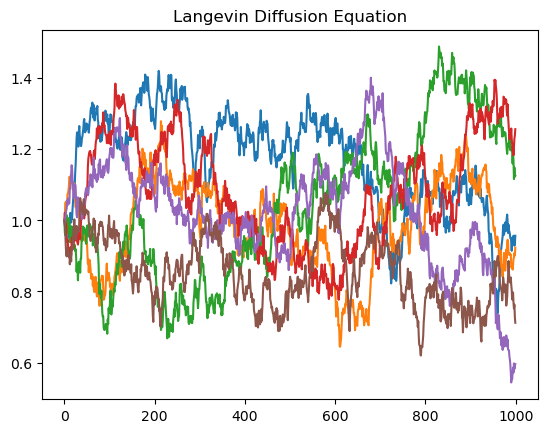

In [112]:
T=10
bins = 1000
dt = T/bins
samples = 6

theta_var=0.5
sigma_var=2
mu_var = 1

X_0=1

def mu(t, x):
    return theta_var*(mu_var-x)

def sigma(t, x):
    return sigma_var


for _ in range(samples):
    X = np.ones(bins)*X_0

    for i in range(1, bins):
        X[i] = X[i-1] + mu(i*dt, X[i-1])*dt + sigma(i*dt, X[i-1])*np.random.normal(0,dt)
    plt.plot(X)

plt.title("Langevin Diffusion Equation")
plt.show()

Let's take the gamma distributoin as the score function.

$$\pi (x)=\frac{x^{\alpha-1} e^{-x / \theta}}{\Gamma(\alpha) \theta^\alpha}$$
then $$\log \pi(x) = \log \left(\frac{x^{\alpha-1} e^{-x / \theta}}{\Gamma(\alpha) \theta^\alpha}\right).$$
Taking the gradient, we have 

\begin{align*}\nabla \log \pi(x) =&\frac{d}{d x}\left(\frac{x^{\alpha - 1}e^{-\frac{x}{\theta}}}{\Gamma(\alpha)\theta^\alpha}\right) \frac{\Gamma(\alpha)\theta^{\alpha}}{x^{\alpha - 1}e^{-\frac{x}{\theta}}} \\
&= \frac{(\alpha -1)x^{\alpha - 2}e^{-\frac{x}{\theta}}-\theta^{-1}x^{\alpha-1}e^{-\frac{x}{\theta}}}{\Gamma(\alpha)\theta^{\alpha}} \frac{\Gamma(\alpha)\theta^{\alpha}}{x^{\alpha - 1}e^{-\frac{x}{\theta}}} \\
&=(\alpha -1)x^{-1}-\theta^{-1}.\end{align*}

This means the langevin dynamics process takes the form

$$dX(t)=\left(\frac{(\alpha -1)}{X(t)}-\frac{1}{\theta}\right) dt + \sqrt{2}dW(t).$$

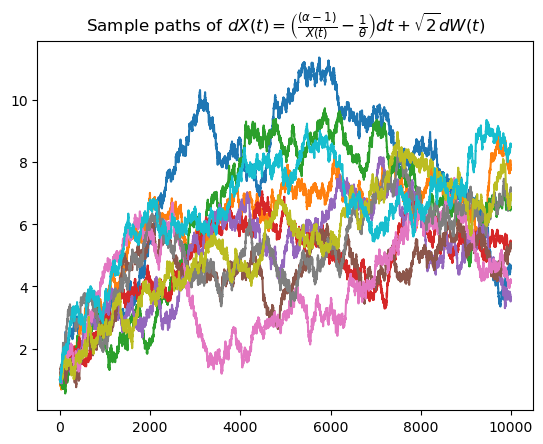

In [207]:
T=10
bins = 10000
dt = T/bins
samples = 10

mu_var = 1
alpha_var = 7.5
theta_var = 1

X_0=1

def mu(t, x):
    return (alpha_var-1)/x - 1/theta_var

def sigma(t, x):
    return np.sqrt(2)

def pi(x, alpha, theta):
    """
    Gamma distribution probability density function:
    π(x) = x^(alpha-1) * exp(-x/theta) / (Gamma(alpha) * theta^alpha)
    """
    return (x**(alpha - 1) * np.exp(-x / theta)) / (
        gamma(alpha) * theta**alpha
    )


X_T = np.zeros(samples)

for sample in range(samples):
    X = np.ones(bins)*X_0

    for i in range(1, bins):
        X[i] = X[i-1] + mu(i*dt, X[i-1])*dt + sigma(i*dt, X[i-1])*np.random.normal(0,math.sqrt(dt))
    plt.plot(X)


plt.title(r"Sample paths of $dX(t)=\left(\frac{(\alpha -1)}{X(t)}-\frac{1}{\theta}\right) dt + \sqrt{2}dW(t)$")

plt.show() 


### Vectorized Version

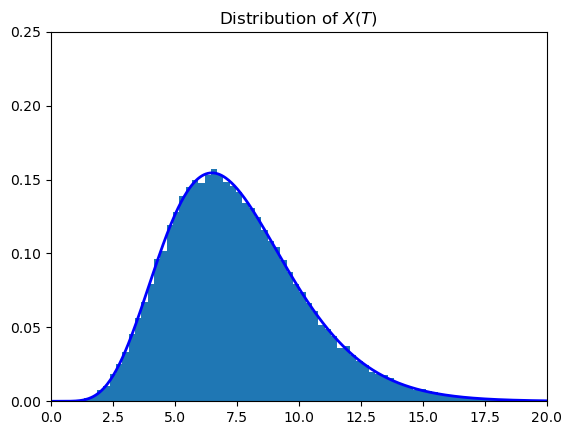

In [200]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

T = 100
bins = 10000
dt = T / bins
samples = 100000

alpha_var = 7.5
theta_var = 1

X_0 = 1

def mu(t, x):
    return (alpha_var - 1) / x - 1 / theta_var

def sigma(t, x):
    return np.sqrt(2)

def pi(x, alpha, theta):
    return (x**(alpha - 1) * np.exp(-x / theta)) / (
        gamma(alpha) * theta**alpha
    )


# All trajectories at current time
X = np.full(samples, X_0, dtype=np.float64)
sqrt_dt = np.sqrt(dt)
sigma_val = np.sqrt(2)

for i in range(1, bins):
    t = i * dt

    X += (
        mu(t, X) * dt
        + sigma_val * np.random.normal(0, sqrt_dt, size=samples)
    )

    # enforce positivity
    X = np.maximum(X, 1e-8)

X_T = X


plt.title("Distribution of $X(T)$")
plt.hist(X_T, density=True, bins=100)

x = np.linspace(0.001, 20, 500)
pi_x = pi(x, alpha_var, theta_var)

plt.plot(x, pi_x, color="blue", linewidth=2)
plt.xlim(0, 20)
plt.ylim(0, 0.25)

plt.show()